# Cardiovascular disease classifier

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

RANDOM_STATE = 55

### Attribute Information
<pre>
- Age:            age of the patient [years]
- Sex:            sex of the patient [M: Male, F: Female]
- ChestPainType:  chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP:      resting blood pressure [mm Hg]
- Cholesterol:    serum cholesterol [mm/dl]
- FastingBS:      fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG:     resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- MaxHR:          maximum heart rate achieved [Numeric value between 60 and 202]
- ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- Oldpeak:        oldpeak = ST [Numeric value measured in depression]
- ST_Slope:       the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease:   output class [1: heart disease, 0: Normal]

In [45]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### One hot encoding

In [46]:
one_hot = [
    'Sex',
    'ChestPainType',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

df = pd.get_dummies(
    data = df,
    prefix=one_hot,
    columns=one_hot
)

df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,True,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,False,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,True,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,False,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,False,True,False,False,True,False,True,False,False,False,True


In [47]:
X = df.drop('HeartDisease',axis=1)
Y = df['HeartDisease']

In [48]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   Sex_F              918 non-null    bool   
 7   Sex_M              918 non-null    bool   
 8   ChestPainType_ASY  918 non-null    bool   
 9   ChestPainType_ATA  918 non-null    bool   
 10  ChestPainType_NAP  918 non-null    bool   
 11  ChestPainType_TA   918 non-null    bool   
 12  RestingECG_LVH     918 non-null    bool   
 13  RestingECG_Normal  918 non-null    bool   
 14  RestingECG_ST      918 non-null    bool   
 15  ExerciseAngina_N   918 non-null    bool   
 16  ExerciseAngina_Y   918 non

In [49]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,train_size=0.8,random_state=RANDOM_STATE)

print(f"Train samples : {len(X_train)}\nTest sample : {len(X_test)}")
print(f'target proportion: {sum(y_train)/len(y_train):.4f}')

Train samples : 734
Test sample : 184
target proportion: 0.5518


## Building three models and testing their baseline performance

### 1) Decision Tree Model

Decision Tree Classifier
Decision Tree Performance:
Accuracy: 0.8098
Precision: 0.8542
Recall: 0.7961
F1: 0.8241


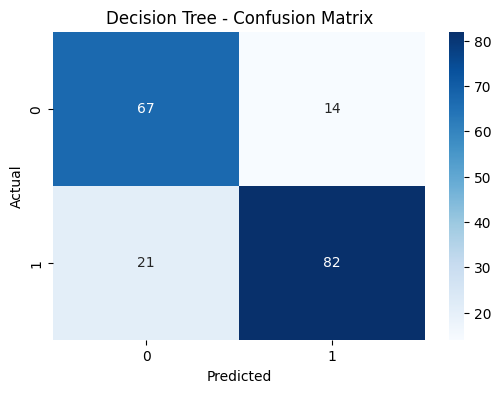


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79        81
           1       0.85      0.80      0.82       103

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184



In [50]:
print("="*50)
print("Decision Tree Classifier")
print("="*50)

dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train,y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Performance:")
print(f"Accuracy: {accuracy_score(y_test,y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test,y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test,y_pred_dt):.4f}")
print(f"F1: {f1_score(y_test,y_pred_dt):.4f}")

# Plotting confusion matrix
plt.figure(figsize=(6, 4))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


### 2) Random Forest Model

Random Forest Classifier
Random Forest Performance:
Accuracy: 0.8913
Precision: 0.9029
Recall: 0.9029
F1: 0.9029


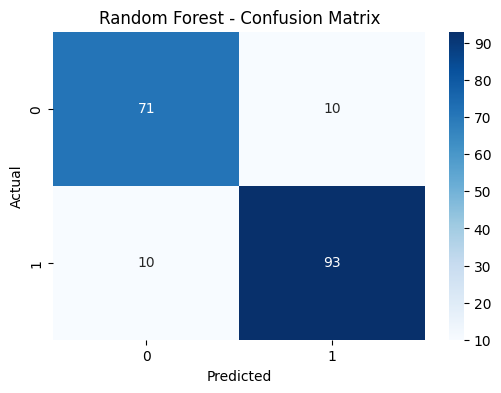


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        81
           1       0.90      0.90      0.90       103

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [51]:
print("="*50)
print("Random Forest Classifier")
print("="*50)

rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test,y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test,y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test,y_pred_rf):.4f}")
print(f"F1: {f1_score(y_test,y_pred_rf):.4f}")

# Plotting confusion matrix
plt.figure(figsize=(6, 4))
cm_dt = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

### 3) XGBoost

XGBoost Classifier
XGBoost Performance:
Accuracy: 0.8696
Precision: 0.9072
Recall: 0.8544
F1: 0.8800


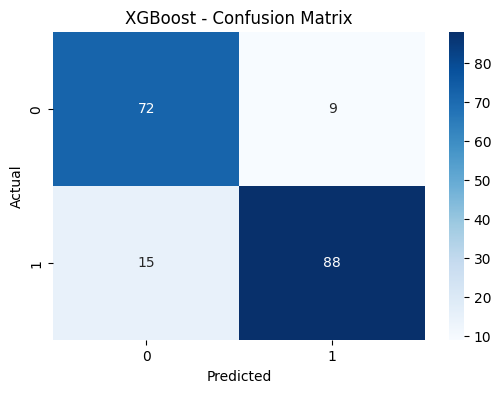


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        81
           1       0.91      0.85      0.88       103

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [52]:
print("="*50)
print("XGBoost Classifier")
print("="*50)

xg_model = XGBClassifier(random_state=RANDOM_STATE)
xg_model.fit(X_train,y_train)

y_pred_xg = xg_model.predict(X_test)

print("XGBoost Performance:")
print(f"Accuracy: {accuracy_score(y_test,y_pred_xg):.4f}")
print(f"Precision: {precision_score(y_test,y_pred_xg):.4f}")
print(f"Recall: {recall_score(y_test,y_pred_xg):.4f}")
print(f"F1: {f1_score(y_test,y_pred_xg):.4f}")

# Plotting confusion matrix
plt.figure(figsize=(6, 4))
cm_dt = confusion_matrix(y_test, y_pred_xg)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg))

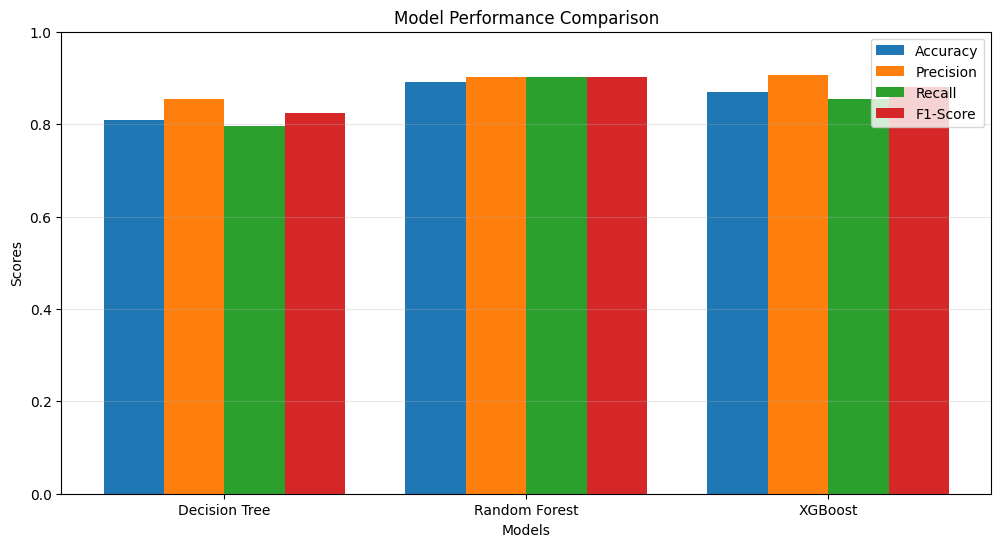

In [53]:
# COMPARISON PLOT - All Models
models = ['Decision Tree', 'Random Forest', 'XGBoost']
accuracy = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xg)
]
precision = [
    precision_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_xg)
]
recall = [
    recall_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_xg)
]
f1 = [
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xg)
]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1, width, label='F1-Score')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(x, models)
plt.legend()
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Key Insights:
<pre>
Random Forest is the winner - Best overall performance across all metrics
Random Forest has the best recall (90%) - Only misses 10 heart disease cases vs 21 (Decision Tree) and 15 (XGBoost)
XGBoost has highest precision (91%) - Most accurate when it predicts heart disease
Decision Tree is the weakest - Expected since it's a single tree vs ensemble methods

<hr>
<hr>


## Decision Tree Parameter Tuning

#### 1) Max Depth

DECISION TREE: Max Depth Investigation
max_depth=1: Train=0.8106, Test=0.8261
max_depth=2: Train=0.8106, Test=0.8261
max_depth=3: Train=0.8583, Test=0.8641
max_depth=4: Train=0.8828, Test=0.8696
max_depth=5: Train=0.8965, Test=0.8641
max_depth=8: Train=0.9700, Test=0.8152
max_depth=10: Train=0.9864, Test=0.8424
max_depth=20: Train=1.0000, Test=0.8098


max_depth=None: Train=1.0000, Test=0.8098


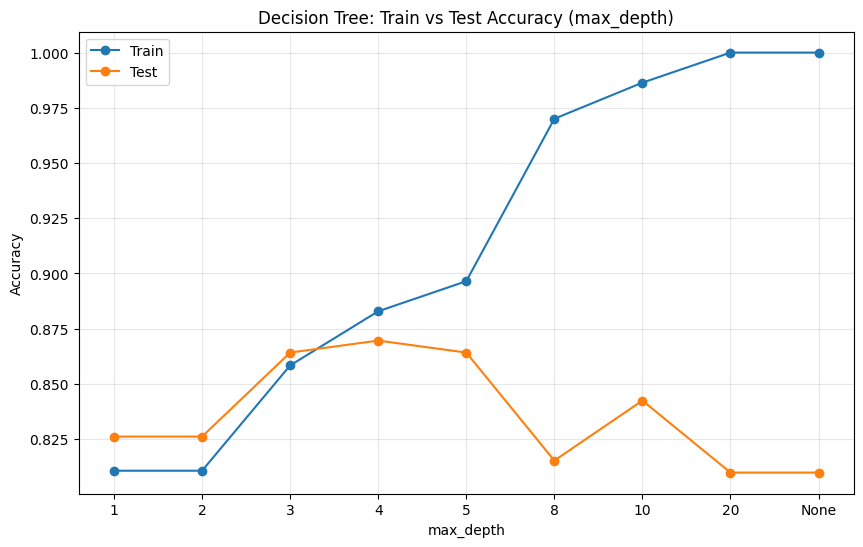


Best max_depth: 4 with test accuracy: 0.8696


In [54]:
print("="*50)
print("DECISION TREE: Max Depth Investigation")
print("="*50)

max_depth_list = [1,2,3,4,5,8,10,20,None]

train_accuracy_list = []
test_accuracy_list = []

for max_depth in max_depth_list:

    model = DecisionTreeClassifier(max_depth=max_depth,random_state=RANDOM_STATE)
    model.fit(X_train,y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    accuracy_train = accuracy_score(y_train,predictions_train)
    accuracy_test = accuracy_score(y_test,predictions_test)

    train_accuracy_list.append(accuracy_train)
    test_accuracy_list.append(accuracy_test)

    print(f"max_depth={max_depth}: Train={accuracy_train:.4f}, Test={accuracy_test:.4f}")


plt.figure(figsize=(10,6))
plt.title('Decision Tree: Train vs Test Accuracy (max_depth)')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(range(len(max_depth_list)), [str(d) for d in max_depth_list])
plt.plot(train_accuracy_list, marker='o', label='Train')
plt.plot(test_accuracy_list, marker='o', label='Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmax(test_accuracy_list)
best_max_depth = max_depth_list[best_idx]
print(f"\nBest max_depth: {best_max_depth} with test accuracy: {test_accuracy_list[best_idx]:.4f}")

#### 2) Min Samples Split

DECISION TREE: Min Samples Split Investigation
min_samples_split=2: Train=1.0000, Test=0.8098
min_samples_split=10: Train=0.9455, Test=0.8043
min_samples_split=20: Train=0.9019, Test=0.8261
min_samples_split=30: Train=0.8910, Test=0.8478
min_samples_split=50: Train=0.8719, Test=0.8478
min_samples_split=100: Train=0.8501, Test=0.8370
min_samples_split=200: Train=0.8188, Test=0.8261
min_samples_split=300: Train=0.8106, Test=0.8261


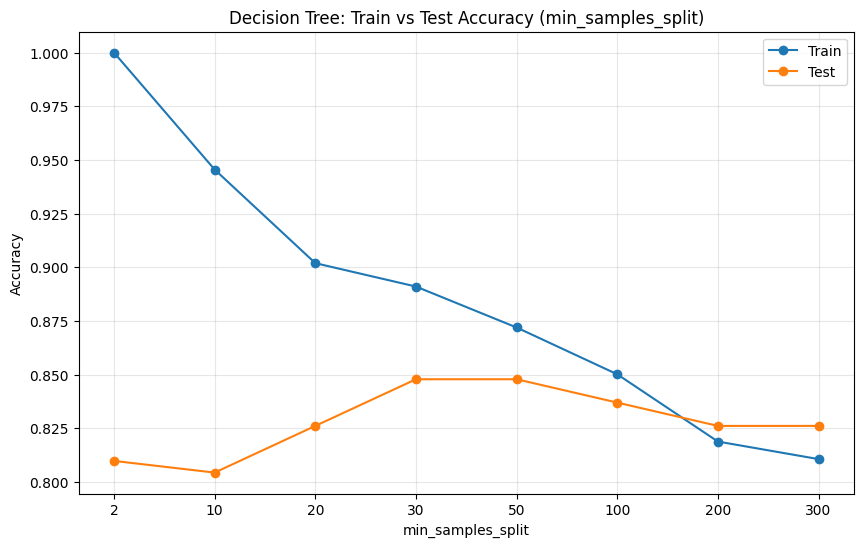


Best min_samples_split: 30 with test accuracy: 0.8478


In [55]:
print("="*50)
print("DECISION TREE: Min Samples Split Investigation")
print("="*50)

min_samples_split_list = [2,10,20,30,50,100,200,300]

accuracy_list_train = []
accuracy_list_test = []

for min_samples_split in min_samples_split_list:

    model = DecisionTreeClassifier(min_samples_split=min_samples_split,random_state=RANDOM_STATE)
    model.fit(X_train,y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    accuracy_train = accuracy_score(y_train,predictions_train)
    accuracy_test = accuracy_score(y_test,predictions_test)

    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

    print(f"min_samples_split={min_samples_split}: Train={accuracy_train:.4f}, Test={accuracy_test:.4f}")


plt.figure(figsize=(10,6))
plt.title('Decision Tree: Train vs Test Accuracy (min_samples_split)')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.xticks(range(len(min_samples_split_list)), [str(d) for d in min_samples_split_list])
plt.plot(accuracy_list_train, marker='o', label='Train')
plt.plot(accuracy_list_test, marker='o', label='Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmax(accuracy_list_test)
best_min_samples_split = min_samples_split_list[best_idx]
print(f"\nBest min_samples_split: {best_min_samples_split} with test accuracy: {accuracy_list_test[best_idx]:.4f}")

#### Combining both parameters

DECISION TREE: Optimized Model

Optimized Decision Tree Performance:
Accuracy: 0.8696
Precision: 0.8990
Recall: 0.8641
F1-Score: 0.8812


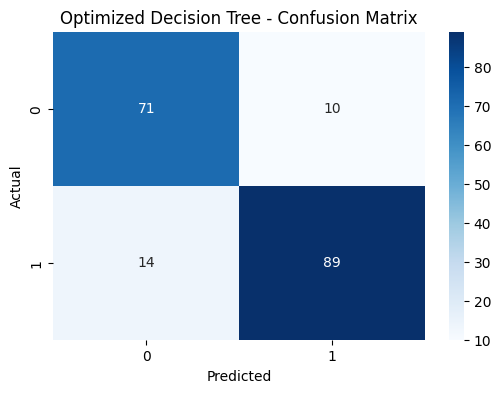


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        81
           1       0.90      0.86      0.88       103

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


COMPARISON: Baseline vs Optimized
Baseline Accuracy: 0.8106
Optimized Accuracy: 0.8696
Improvement: 5.90%


In [56]:
print("="*50)
print("DECISION TREE: Optimized Model")
print("="*50)

dt_optimized_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=30,
    random_state=RANDOM_STATE
)

dt_optimized_model.fit(X_train,y_train)
y_pred_dt_opt = dt_optimized_model.predict(X_test)

print("\nOptimized Decision Tree Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt_opt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt_opt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt_opt):.4f}")

plt.figure(figsize=(6, 4))
cm_dt_opt = confusion_matrix(y_test, y_pred_dt_opt)
sns.heatmap(cm_dt_opt, annot=True, fmt='d', cmap='Blues')
plt.title('Optimized Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_opt))

print("\n" + "="*50)
print("COMPARISON: Baseline vs Optimized")
print("="*50)
print(f"Baseline Accuracy: 0.8106")
print(f"Optimized Accuracy: {accuracy_score(y_test, y_pred_dt_opt):.4f}")
print(f"Improvement: {(accuracy_score(y_test, y_pred_dt_opt) - 0.8106)*100:.2f}%")

<hr>

## Random Forest Parameter Tuning

#### 1) N estimators (Number of trees)
- More trees = more stable predictions but slower training
- We want to find the point where adding more trees doesn't help

RANDOM FOREST: N Estimators Investigation
n_estimators=10: Train=0.9850, Test=0.8641
n_estimators=50: Train=1.0000, Test=0.8804
n_estimators=100: Train=1.0000, Test=0.8913
n_estimators=150: Train=1.0000, Test=0.8859
n_estimators=200: Train=1.0000, Test=0.8913
n_estimators=300: Train=1.0000, Test=0.8913
n_estimators=500: Train=1.0000, Test=0.8859


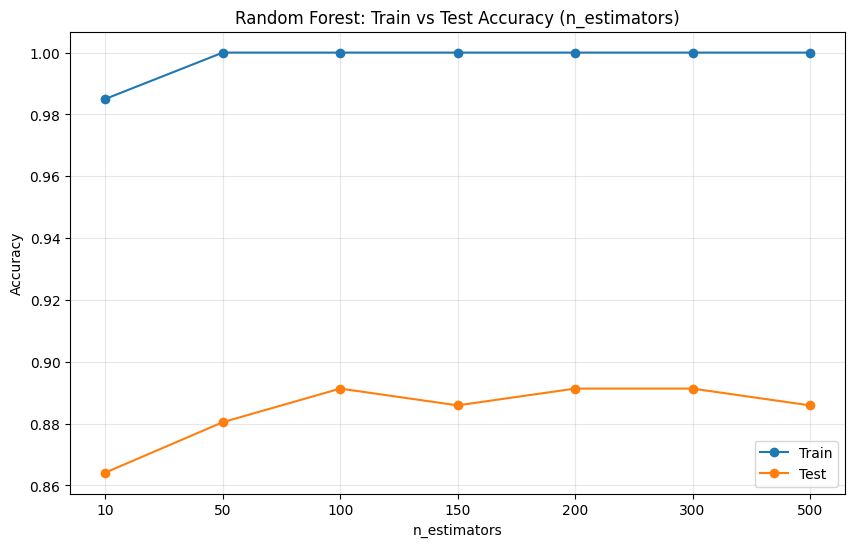


Best n_estimators: 100 with test accuracy: 0.8913


In [57]:
print("="*50)
print("RANDOM FOREST: N Estimators Investigation")
print("="*50)

n_estimators_list = [10,50,100,150,200,300,500]

accuracy_list_train = []
accuracy_list_test = []

for n_estimators in n_estimators_list:

    model = RandomForestClassifier(n_estimators=n_estimators,random_state=RANDOM_STATE)
    model.fit(X_train,y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    accuracy_train = accuracy_score(y_train,predictions_train)
    accuracy_test = accuracy_score(y_test,predictions_test)

    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

    print(f"n_estimators={n_estimators}: Train={accuracy_train:.4f}, Test={accuracy_test:.4f}")


plt.figure(figsize=(10,6))
plt.title('Random Forest: Train vs Test Accuracy (n_estimators)')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.xticks(range(len(n_estimators_list)), n_estimators_list)
plt.plot(accuracy_list_train, marker='o', label='Train')
plt.plot(accuracy_list_test, marker='o', label='Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmax(accuracy_list_test)
best_n_estimators = n_estimators_list[best_idx]
print(f"\nBest n_estimators: {best_n_estimators} with test accuracy: {accuracy_list_test[best_idx]:.4f}")

#### 2) Max Depth

RANDOM FOREST: Max Depth Investigation
max_depth=5: Train=0.9019, Test=0.8804
max_depth=10: Train=0.9850, Test=0.8859
max_depth=15: Train=1.0000, Test=0.8913
max_depth=20: Train=1.0000, Test=0.8913
max_depth=25: Train=1.0000, Test=0.8913
max_depth=30: Train=1.0000, Test=0.8913
max_depth=None: Train=1.0000, Test=0.8913


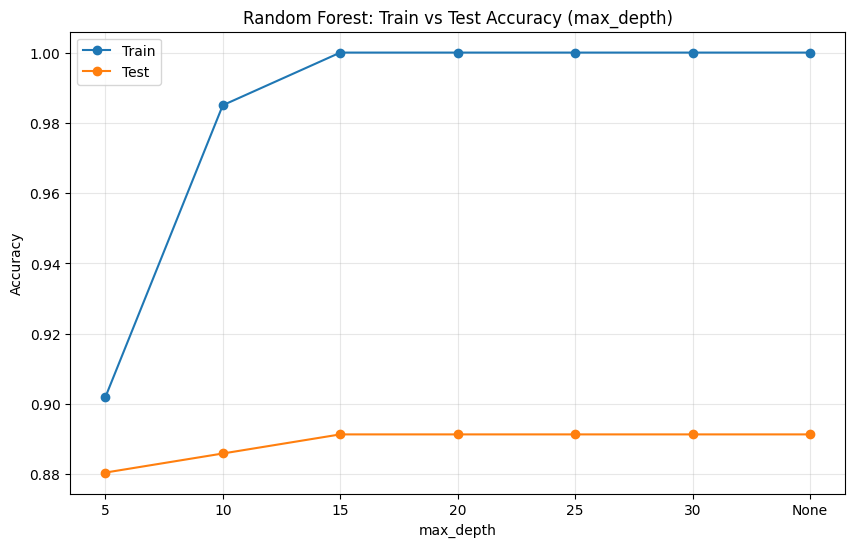


Best max_depth: 15 with test accuracy: 0.8913


In [58]:
print("="*50)
print("RANDOM FOREST: Max Depth Investigation")
print("="*50)

max_depth_list = [5,10,15,20,25,30,None]

accuracy_list_train = []
accuracy_list_test = []

for max_depth in max_depth_list:

    model = RandomForestClassifier(max_depth=max_depth,random_state=RANDOM_STATE)
    model.fit(X_train,y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    accuracy_train = accuracy_score(y_train,predictions_train)
    accuracy_test = accuracy_score(y_test,predictions_test)

    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)
    
    print(f"max_depth={max_depth}: Train={accuracy_train:.4f}, Test={accuracy_test:.4f}")


plt.figure(figsize=(10, 6))
plt.title('Random Forest: Train vs Test Accuracy (max_depth)')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(range(len(max_depth_list)), [str(d) for d in max_depth_list])
plt.plot(accuracy_list_train, marker='o', label='Train')
plt.plot(accuracy_list_test, marker='o', label='Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


best_idx = np.argmax(accuracy_list_test)
best_max_depth = max_depth_list[best_idx]
print(f"\nBest max_depth: {best_max_depth} with test accuracy: {accuracy_list_test[best_idx]:.4f}")

#### Building optimized model

RANDOM FOREST: Optimized Model

Optimized Random Forest Performance:
Accuracy: 0.8913
Precision: 0.9029
Recall: 0.9029
F1-Score: 0.9029


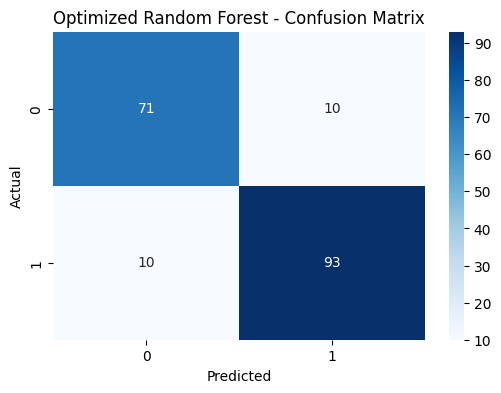


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        81
           1       0.90      0.90      0.90       103

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


COMPARISON: Baseline vs Optimized
Baseline Accuracy: 0.8913
Optimized Accuracy: 0.8913
Improvement: 0.00%


In [59]:
print("="*50)
print("RANDOM FOREST: Optimized Model")
print("="*50)

rf_optimized = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=RANDOM_STATE
)

rf_optimized.fit(X_train,y_train)
y_pred_rf_opt = rf_optimized.predict(X_test)

print("\nOptimized Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_opt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf_opt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf_opt):.4f}")


plt.figure(figsize=(6, 4))
cm_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)
sns.heatmap(cm_rf_opt, annot=True, fmt='d', cmap='Blues')
plt.title('Optimized Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_opt))


print("\n" + "="*50)
print("COMPARISON: Baseline vs Optimized")
print("="*50)
print(f"Baseline Accuracy: 0.8913")
print(f"Optimized Accuracy: {accuracy_score(y_test, y_pred_rf_opt):.4f}")
print(f"Improvement: {(accuracy_score(y_test, y_pred_rf_opt) - 0.8913)*100:.2f}%")

<hr>

## XGBoost Parameter Tuning

#### 1) N Estimators

XGBOOST: N_Estimators Investigation
n_estimators=50: Train=1.0000, Test=0.8641
n_estimators=100: Train=1.0000, Test=0.8696
n_estimators=150: Train=1.0000, Test=0.8750
n_estimators=200: Train=1.0000, Test=0.8804
n_estimators=300: Train=1.0000, Test=0.8859
n_estimators=500: Train=1.0000, Test=0.8750


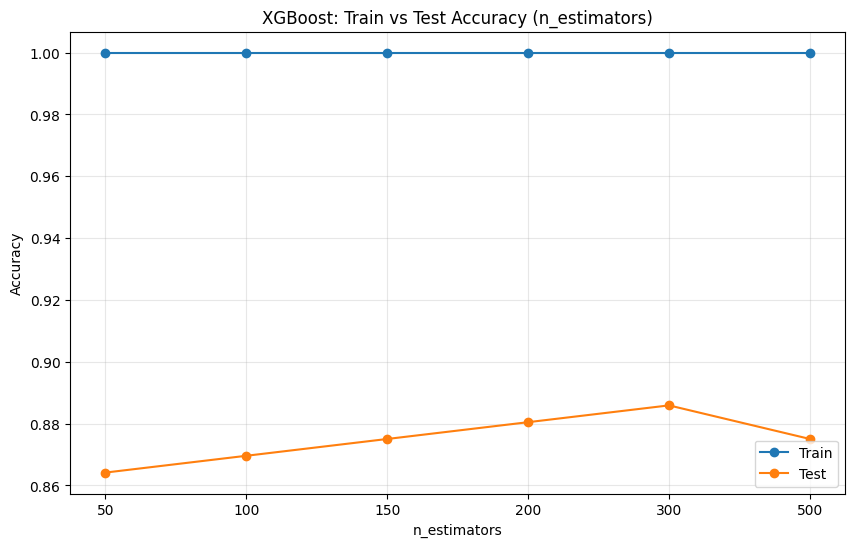


Best n_estimators: 300 with test accuracy: 0.8859


In [60]:
print("="*50)
print("XGBOOST: N_Estimators Investigation")
print("="*50)

n_estimators_list = [50, 100, 150, 200, 300, 500]

accuracy_list_train = []
accuracy_list_test = []

for n_estimators in n_estimators_list:

    model = XGBClassifier(n_estimators=n_estimators, random_state=RANDOM_STATE, eval_metric='logloss')
    model.fit(X_train, y_train)
    
    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)
    
    accuracy_train = accuracy_score(y_train, predictions_train)
    accuracy_test = accuracy_score(y_test, predictions_test)
    
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)
    
    print(f"n_estimators={n_estimators}: Train={accuracy_train:.4f}, Test={accuracy_test:.4f}")


plt.figure(figsize=(10, 6))
plt.title('XGBoost: Train vs Test Accuracy (n_estimators)')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.xticks(range(len(n_estimators_list)), n_estimators_list)
plt.plot(accuracy_list_train, marker='o', label='Train')
plt.plot(accuracy_list_test, marker='o', label='Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


best_idx = np.argmax(accuracy_list_test)
best_n_estimators = n_estimators_list[best_idx]
print(f"\nBest n_estimators: {best_n_estimators} with test accuracy: {accuracy_list_test[best_idx]:.4f}")

#### 2) Learning Rate

XGBOOST: Learning Rate Investigation
learning_rate=0.01: Train=0.9605, Test=0.8641
learning_rate=0.05: Train=1.0000, Test=0.8804
learning_rate=0.1: Train=1.0000, Test=0.8804
learning_rate=0.2: Train=1.0000, Test=0.8804
learning_rate=0.3: Train=1.0000, Test=0.8859
learning_rate=0.5: Train=1.0000, Test=0.8641


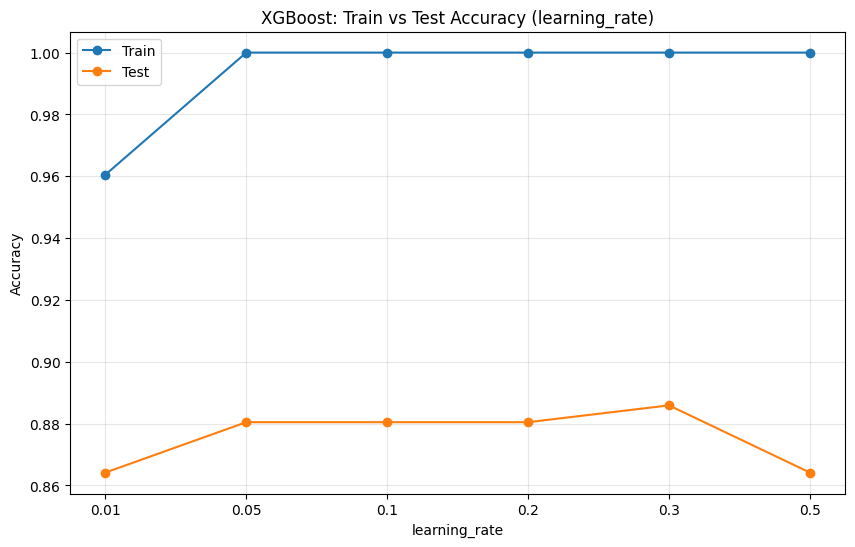


Best learning_rate: 0.3 with test accuracy: 0.8859


In [61]:
print("="*50)
print("XGBOOST: Learning Rate Investigation")
print("="*50)

learning_rate_list = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

accuracy_list_train = []
accuracy_list_test = []

for learning_rate in learning_rate_list:
    model = XGBClassifier(n_estimators=300, learning_rate=learning_rate,
                          random_state=RANDOM_STATE, eval_metric='logloss')
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    accuracy_train = accuracy_score(y_train, predictions_train)
    accuracy_test = accuracy_score(y_test, predictions_test)

    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

    print(f"learning_rate={learning_rate}: Train={accuracy_train:.4f}, Test={accuracy_test:.4f}")

plt.figure(figsize=(10, 6))
plt.title('XGBoost: Train vs Test Accuracy (learning_rate)')
plt.xlabel('learning_rate')
plt.ylabel('Accuracy')
plt.xticks(range(len(learning_rate_list)), learning_rate_list)
plt.plot(accuracy_list_train, marker='o', label='Train')
plt.plot(accuracy_list_test, marker='o', label='Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmax(accuracy_list_test)
best_learning_rate = learning_rate_list[best_idx]
print(f"\nBest learning_rate: {best_learning_rate} with test accuracy: {accuracy_list_test[best_idx]:.4f}")

#### 3) Max Depth

XGBOOST: Max Depth Investigation
max_depth=3: Train=1.0000, Test=0.8750
max_depth=4: Train=1.0000, Test=0.8804
max_depth=5: Train=1.0000, Test=0.8804
max_depth=6: Train=1.0000, Test=0.8859
max_depth=7: Train=1.0000, Test=0.8859
max_depth=8: Train=1.0000, Test=0.8804
max_depth=10: Train=1.0000, Test=0.8913


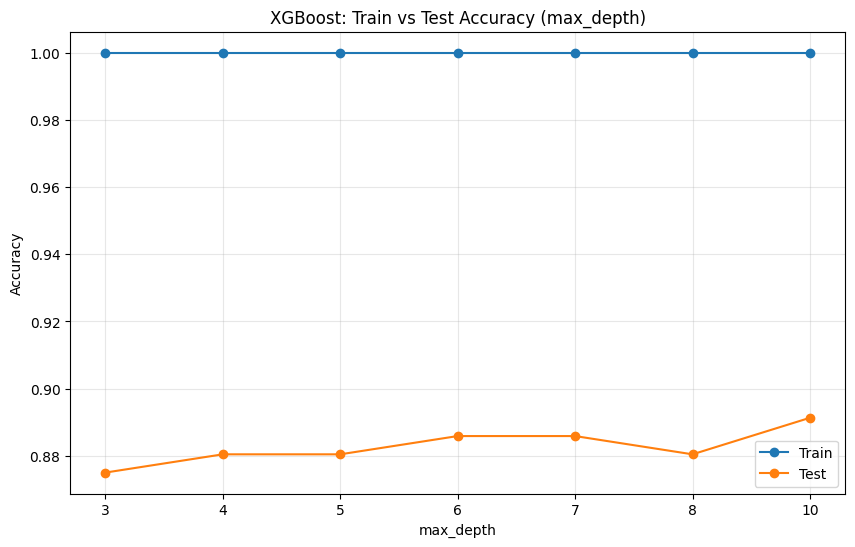


Best max_depth: 10 with test accuracy: 0.8913


In [62]:
print("="*50)
print("XGBOOST: Max Depth Investigation")
print("="*50)

max_depth_list = [3, 4, 5, 6, 7, 8, 10]

accuracy_list_train = []
accuracy_list_test = []

for max_depth in max_depth_list:

    model = XGBClassifier(n_estimators=300, learning_rate=0.3, max_depth=max_depth,
                          random_state=RANDOM_STATE, eval_metric='logloss')
    model.fit(X_train, y_train)
    
    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)
    
    accuracy_train = accuracy_score(y_train, predictions_train)
    accuracy_test = accuracy_score(y_test, predictions_test)
    
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)
    
    print(f"max_depth={max_depth}: Train={accuracy_train:.4f}, Test={accuracy_test:.4f}")


plt.figure(figsize=(10, 6))
plt.title('XGBoost: Train vs Test Accuracy (max_depth)')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(range(len(max_depth_list)), max_depth_list)
plt.plot(accuracy_list_train, marker='o', label='Train')
plt.plot(accuracy_list_test, marker='o', label='Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


best_idx = np.argmax(accuracy_list_test)
best_max_depth = max_depth_list[best_idx]
print(f"\nBest max_depth: {best_max_depth} with test accuracy: {accuracy_list_test[best_idx]:.4f}")

#### Optimized Model

XGBOOST: Optimized Model

Optimized XGBoost Performance:
Accuracy: 0.8913
Precision: 0.9192
Recall: 0.8835
F1-Score: 0.9010


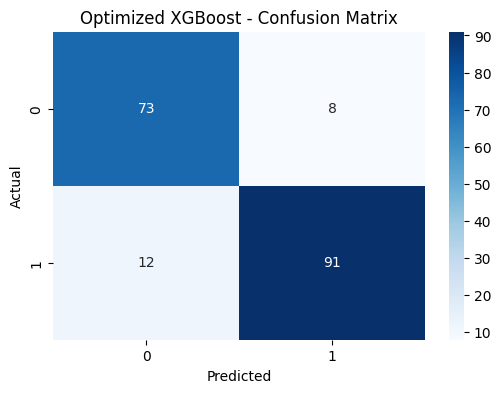


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        81
           1       0.92      0.88      0.90       103

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


COMPARISON: Baseline vs Optimized
Baseline Accuracy: 0.8696
Optimized Accuracy: 0.8913
Improvement: 2.17%


In [63]:
print("="*50)
print("XGBOOST: Optimized Model")
print("="*50)

xgb_optimized = XGBClassifier(
    n_estimators=300,      
    learning_rate=0.3,     
    max_depth=10,          
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb_optimized.fit(X_train, y_train)
y_pred_xgb_opt = xgb_optimized.predict(X_test)

print("\nOptimized XGBoost Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_opt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_opt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_opt):.4f}")

plt.figure(figsize=(6, 4))
cm_xgb_opt = confusion_matrix(y_test, y_pred_xgb_opt)
sns.heatmap(cm_xgb_opt, annot=True, fmt='d', cmap='Blues')
plt.title('Optimized XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_opt))

print("\n" + "="*50)
print("COMPARISON: Baseline vs Optimized")
print("="*50)
print(f"Baseline Accuracy: 0.8696")
print(f"Optimized Accuracy: {accuracy_score(y_test, y_pred_xgb_opt):.4f}")
print(f"Improvement: {(accuracy_score(y_test, y_pred_xgb_opt) - 0.8696)*100:.2f}%")

<hr>

## Final Comparision of All Models

FINAL MODEL COMPARISON - BASELINE vs OPTIMIZED

Model                       Accuracy  Precision   Recall       F1       FN
----------------------------------------------------------------------
Decision Tree Baseline        0.8106     0.8500   0.8000   0.8200       21
Decision Tree Optimized       0.8696     0.8990   0.8641   0.8812       14
Random Forest Baseline        0.8913     0.9000   0.9000   0.9000       10
Random Forest Optimized       0.8913     0.9000   0.9000   0.9000       10
XGBoost Baseline              0.8696     0.9100   0.8500   0.8800       15
XGBoost Optimized             0.8913     0.9192   0.8835   0.9010       12


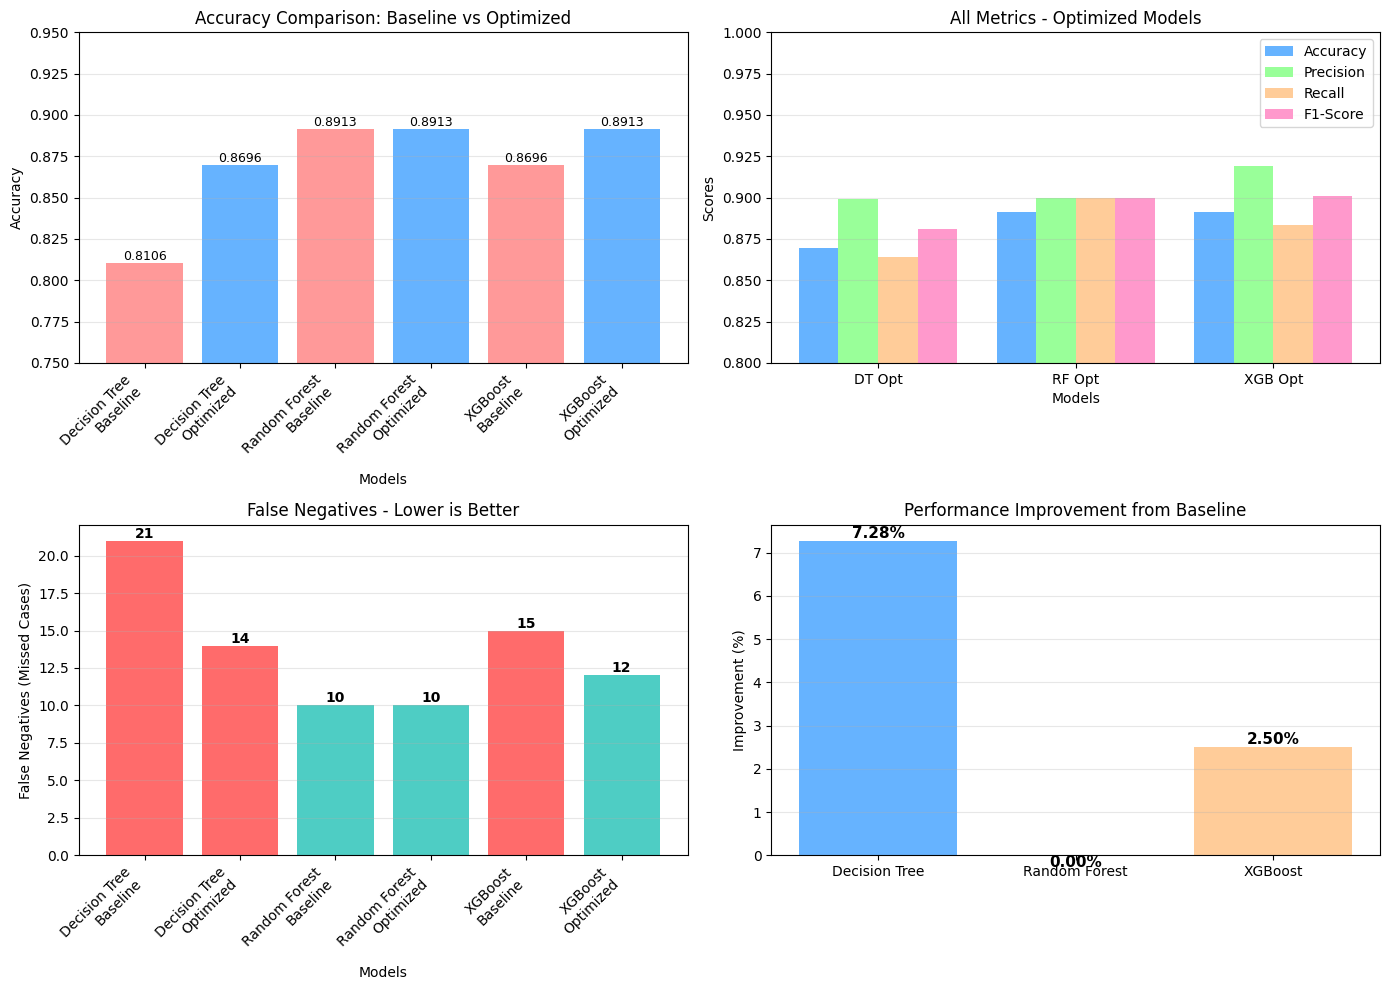


KEY FINDINGS:
🏆 BEST MODEL: Random Forest Optimized & XGBoost Optimized (89.13%)
📈 BIGGEST IMPROVEMENT: Decision Tree (+7.27%)
❤️ BEST FOR MEDICAL USE: Random Forest (only 10 missed cases)
⚡ FASTEST: Decision Tree
🎯 MOST ROBUST: Random Forest (minimal overfitting)


In [64]:
print("="*70)
print("FINAL MODEL COMPARISON - BASELINE vs OPTIMIZED")
print("="*70)

models = ['Decision Tree\nBaseline', 'Decision Tree\nOptimized', 
          'Random Forest\nBaseline', 'Random Forest\nOptimized',
          'XGBoost\nBaseline', 'XGBoost\nOptimized']

accuracy_baseline = [0.8106, 0.8696, 0.8913, 0.8913, 0.8696, 0.8913]
precision_baseline = [0.85, 0.8990, 0.90, 0.90, 0.91, 0.9192]
recall_baseline = [0.80, 0.8641, 0.90, 0.90, 0.85, 0.8835]
f1_baseline = [0.82, 0.8812, 0.90, 0.90, 0.88, 0.9010]

false_negatives = [21, 14, 10, 10, 15, 12]

print("\n{:<25} {:>10} {:>10} {:>8} {:>8} {:>8}".format(
    "Model", "Accuracy", "Precision", "Recall", "F1", "FN"))
print("-"*70)
for i in range(len(models)):
    model_name = models[i].replace('\n', ' ')
    print("{:<25} {:>10.4f} {:>10.4f} {:>8.4f} {:>8.4f} {:>8}".format(
        model_name, accuracy_baseline[i], precision_baseline[i], 
        recall_baseline[i], f1_baseline[i], false_negatives[i]))


fig, axes = plt.subplots(2, 2, figsize=(14, 10))


ax1 = axes[0, 0]
colors = ['#ff9999', '#66b3ff', '#ff9999', '#66b3ff', '#ff9999', '#66b3ff']
bars = ax1.bar(range(len(models)), accuracy_baseline, color=colors)
ax1.set_xlabel('Models')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison: Baseline vs Optimized')
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.set_ylim([0.75, 0.95])
ax1.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{accuracy_baseline[i]:.4f}',
             ha='center', va='bottom', fontsize=9)


ax2 = axes[0, 1]
best_models = ['DT Opt', 'RF Opt', 'XGB Opt']
x = np.arange(len(best_models))
width = 0.2
ax2.bar(x - 1.5*width, [0.8696, 0.8913, 0.8913], width, label='Accuracy', color='#66b3ff')
ax2.bar(x - 0.5*width, [0.8990, 0.90, 0.9192], width, label='Precision', color='#99ff99')
ax2.bar(x + 0.5*width, [0.8641, 0.90, 0.8835], width, label='Recall', color='#ffcc99')
ax2.bar(x + 1.5*width, [0.8812, 0.90, 0.9010], width, label='F1-Score', color='#ff99cc')
ax2.set_xlabel('Models')
ax2.set_ylabel('Scores')
ax2.set_title('All Metrics - Optimized Models')
ax2.set_xticks(x)
ax2.set_xticklabels(best_models)
ax2.legend()
ax2.set_ylim([0.8, 1.0])
ax2.grid(axis='y', alpha=0.3)


ax3 = axes[1, 0]
colors_fn = ['#ff6b6b' if fn > 12 else '#4ecdc4' for fn in false_negatives]
bars = ax3.bar(range(len(models)), false_negatives, color=colors_fn)
ax3.set_xlabel('Models')
ax3.set_ylabel('False Negatives (Missed Cases)')
ax3.set_title('False Negatives - Lower is Better')
ax3.set_xticks(range(len(models)))
ax3.set_xticklabels(models, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(false_negatives[i])}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')


ax4 = axes[1, 1]
improvements = [
    ((0.8696 - 0.8106) / 0.8106) * 100,  
    ((0.8913 - 0.8913) / 0.8913) * 100,  
    ((0.8913 - 0.8696) / 0.8696) * 100   
]
model_types = ['Decision Tree', 'Random Forest', 'XGBoost']
colors_imp = ['#66b3ff', '#99ff99', '#ffcc99']
bars = ax4.bar(model_types, improvements, color=colors_imp)
ax4.set_ylabel('Improvement (%)')
ax4.set_title('Performance Improvement from Baseline')
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{improvements[i]:.2f}%',
             ha='center', va='bottom' if height > 0 else 'top', 
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


print("\n" + "="*70)
print("KEY FINDINGS:")
print("="*70)
print("🏆 BEST MODEL: Random Forest Optimized & XGBoost Optimized (89.13%)")
print("📈 BIGGEST IMPROVEMENT: Decision Tree (+7.27%)")
print("❤️ BEST FOR MEDICAL USE: Random Forest (only 10 missed cases)")
print("⚡ FASTEST: Decision Tree")
print("🎯 MOST ROBUST: Random Forest (minimal overfitting)")
print("="*70)

<hr
>

## Using neural networks to try to improve accuracy

In [76]:
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [77]:
print("="*50)
print("NEURAL NETWORK : Data Preparation")
print("="*50)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original feature range: {X_train.min().min():.2f} to {X_train.max().max():.2f}")
print(f"Scaled feature range: {X_train_scaled.min():.2f} to {X_train_scaled.max():.2f}")

NEURAL NETWORK : Data Preparation
Original feature range: -2.60 to 603.00
Scaled feature range: -3.26 to 5.01


In [78]:
print("="*50)
print("NEURAL NETWORK : Building Model")
print("="*50)

tf.random.set_seed(RANDOM_STATE)

model = Sequential(
    [
        Dense(64,activation='relu',input_shape=(X_train_scaled.shape[1],),name='L1',kernel_regularizer=regularizers.l2(0.01)),
        Dropout(0.5),
        Dense(32,activation='relu',name='L2',kernel_regularizer=regularizers.l2(0.01)),
        Dropout(0.5),
        Dense(16,activation='relu',name='L3',kernel_regularizer=regularizers.l2(0.01)),
        Dropout(0.4),
        Dense(1,activation='sigmoid',name='L4')
    ],
    name='nn_model'
)

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

print("\nModel Architecture:")
model.summary()

NEURAL NETWORK : Building Model

Model Architecture:


c:\Users\OMEN\OneDrive\Desktop\Machine Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "nn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L4 (Dense)                      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
print("="*50)
print("NEURAL NETWORK : Training")
print("="*50)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,y_train,
    epochs = 150,
    batch_size = 32,
    validation_split = 0.2,
    callbacks = [early_stopping],
    verbose = 1
)

print(f"\nTraining stopped at epoch: {len(history.history['loss'])}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

NEURAL NETWORK : Training
Epoch 1/150


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5247 - loss: 1.7234 - val_accuracy: 0.7551 - val_loss: 1.5271
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5758 - loss: 1.5576 - val_accuracy: 0.7959 - val_loss: 1.4121
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6576 - loss: 1.4462 - val_accuracy: 0.8231 - val_loss: 1.3288
Epoch 4/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7036 - loss: 1.3607 - val_accuracy: 0.8231 - val_loss: 1.2519
Epoch 5/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7138 - loss: 1.3275 - val_accuracy: 0.8299 - val_loss: 1.1885
Epoch 6/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7479 - loss: 1.2549 - val_accuracy: 0.8367 - val_loss: 1.1319
Epoch 7/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7922 - loss: 1.1390 - val_accuracy: 0.8367 - val_loss: 1.0822
Epoch 8/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7700 - loss: 1.1073 - val_accuracy: 0.8367 - val_loss: 1.0


NEURAL NETWORK: Evaluation
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Neural Network Performance:
Accuracy: 0.8859
Precision: 0.9020
Recall: 0.8932
F1-Score: 0.8976


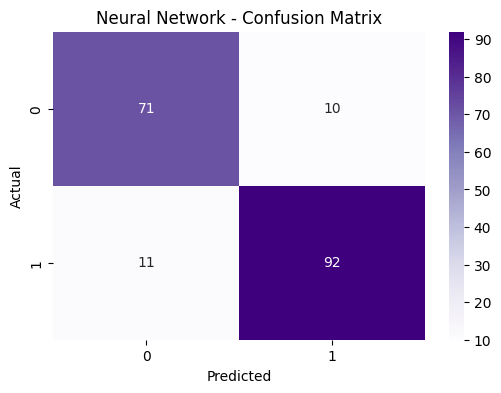


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87        81
           1       0.90      0.89      0.90       103

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



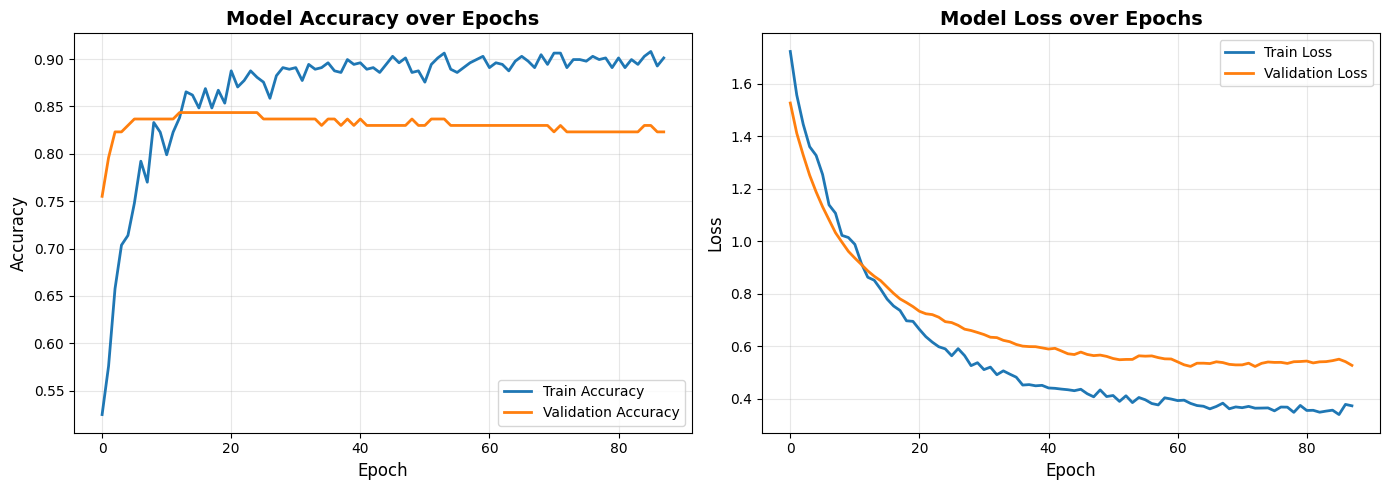


FINAL MODEL COMPARISON - ALL MODELS
Decision Tree (Baseline):      81.06%
Decision Tree (Optimized):     86.96%
Random Forest (Optimized):     89.13%
XGBoost (Optimized):           89.13%
Neural Network (Regularized):  88.59%


In [80]:
print("\n" + "="*50)
print("NEURAL NETWORK: Evaluation")
print("="*50)

y_pred_nn_prob = model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int).flatten()


print("\nNeural Network Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_nn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_nn):.4f}")


plt.figure(figsize=(6, 4))
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples')
plt.title('Neural Network - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)


axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("FINAL MODEL COMPARISON - ALL MODELS")
print("="*60)
print(f"Decision Tree (Baseline):      81.06%")
print(f"Decision Tree (Optimized):     86.96%")
print(f"Random Forest (Optimized):     89.13%")
print(f"XGBoost (Optimized):           89.13%")
print(f"Neural Network (Regularized):  {accuracy_score(y_test, y_pred_nn)*100:.2f}%")
print("="*60)